In [2]:
import torch
import torch.nn as nn

input_tensor = torch.tensor(
    [[[[ 20,  18,  29, 168,  75, 109,  77, 172],
       [122,  87, 154, 149, 159, 179, 253,  18],
       [ 79,  73, 174,  78, 189,  30,  49,  76],
       [122, 174,  38, 249, 208, 182, 113,  81],
       [ 17, 128,  13,  86, 149, 222, 135,  17],
       [236,  85,  99,  57,  13,  55, 223, 117],
       [177,  32, 168, 150, 160, 199, 196, 187],
       [155, 124, 191,  56, 207,  44, 203,  83]]]],
    dtype=torch.float32  
)
# 배치크기 1, 채널수 1, 높이 8, 너비 8 
print("입력 데이터\n",input_tensor)
print("입력 데이터의 형태\n", input_tensor.shape)

입력 데이터
 tensor([[[[ 20.,  18.,  29., 168.,  75., 109.,  77., 172.],
          [122.,  87., 154., 149., 159., 179., 253.,  18.],
          [ 79.,  73., 174.,  78., 189.,  30.,  49.,  76.],
          [122., 174.,  38., 249., 208., 182., 113.,  81.],
          [ 17., 128.,  13.,  86., 149., 222., 135.,  17.],
          [236.,  85.,  99.,  57.,  13.,  55., 223., 117.],
          [177.,  32., 168., 150., 160., 199., 196., 187.],
          [155., 124., 191.,  56., 207.,  44., 203.,  83.]]]])
입력 데이터의 형태
 torch.Size([1, 1, 8, 8])


In [4]:
#Conv2d 레이어 생성, 스트라이드 1를 적용
conv_layer_stride_one = nn.Conv2d(1, 1, kernel_size=3, stride=1)
#in_channels=1, out_channels=1, kernel_size=3, stride=1
#kernel size=3은 3x3 필터를 사용한다는 의미, stride=1은 필터를 한 칸씩 이동하며 합성곱 연산을 수행한다는 의미
output_tensor_stride = conv_layer_stride_one(input_tensor)

print('Output shape with stride:', output_tensor_stride.shape)

Output shape with stride: torch.Size([1, 1, 6, 6])


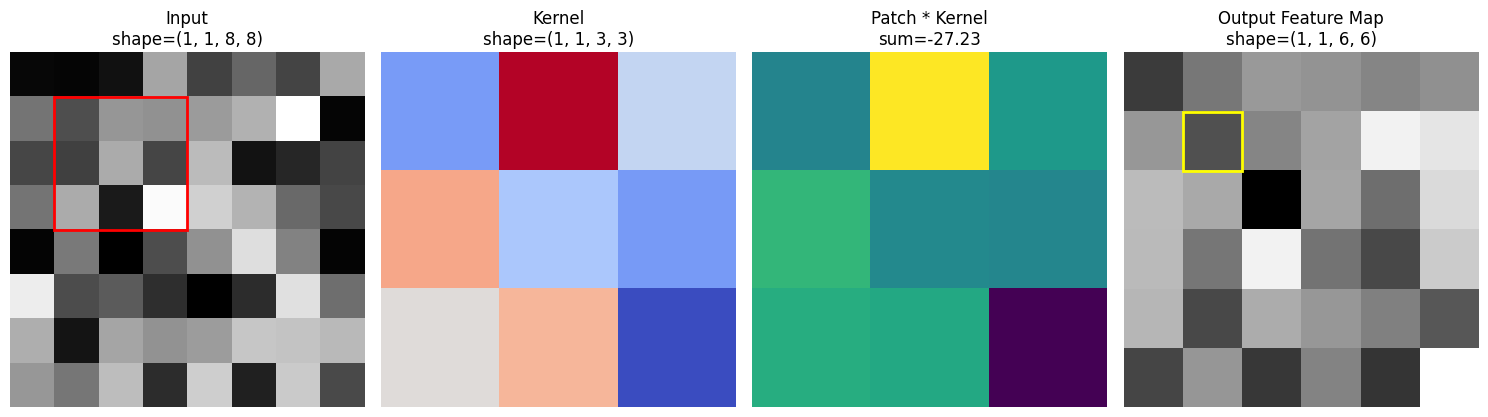

[요약]
input shape : (1, 1, 8, 8)
kernel shape: (1, 1, 3, 3)
output shape: (1, 1, 6, 6)
선택 위치 patch sum(product): -27.2311


In [5]:
# CNN tensor 처리 과정을 시각화하는 함수
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def visualize_conv_tensor_flow(input_tensor, conv_layer, output_tensor, rf_top_left=(0, 0)):
    """
    input_tensor: (N, C, H, W)
    conv_layer: nn.Conv2d
    output_tensor: (N, C_out, H_out, W_out)
    rf_top_left: 입력에서 확인할 receptive field 좌상단 좌표 (row, col)
    """
    x = input_tensor[0, 0].detach().cpu().numpy()
    w = conv_layer.weight[0, 0].detach().cpu().numpy()
    y = output_tensor[0, 0].detach().cpu().numpy()

    k = conv_layer.kernel_size[0] if isinstance(conv_layer.kernel_size, tuple) else conv_layer.kernel_size
    s = conv_layer.stride[0] if isinstance(conv_layer.stride, tuple) else conv_layer.stride

    r, c = rf_top_left

    fig = plt.figure(figsize=(15, 4))

    # 1) 입력 텐서
    ax1 = fig.add_subplot(1, 4, 1)
    ax1.imshow(x, cmap="gray")
    ax1.set_title(f"Input\nshape={tuple(input_tensor.shape)}")
    ax1.axis("off")

    # receptive field 표시
    rect = Rectangle((c - 0.5, r - 0.5), k, k, fill=False, edgecolor="red", linewidth=2)
    ax1.add_patch(rect)

    # 2) 커널
    ax2 = fig.add_subplot(1, 4, 2)
    ax2.imshow(w, cmap="coolwarm")
    ax2.set_title(f"Kernel\nshape={tuple(conv_layer.weight.shape)}")
    ax2.axis("off")

    # 3) 곱셈 결과 (한 위치)
    patch = x[r:r + k, c:c + k]
    multiplied = patch * w
    ax3 = fig.add_subplot(1, 4, 3)
    ax3.imshow(multiplied, cmap="viridis")
    ax3.set_title(
        "Patch * Kernel\n"
        f"sum={multiplied.sum():.2f}"
    )
    ax3.axis("off")

    # 4) 출력 피처맵
    ax4 = fig.add_subplot(1, 4, 4)
    ax4.imshow(y, cmap="gray")
    ax4.set_title(f"Output Feature Map\nshape={tuple(output_tensor.shape)}")
    ax4.axis("off")

    out_r, out_c = r // s, c // s
    if out_r < y.shape[0] and out_c < y.shape[1]:
        rect_out = Rectangle((out_c - 0.5, out_r - 0.5), 1, 1, fill=False, edgecolor="yellow", linewidth=2)
        ax4.add_patch(rect_out)

    plt.tight_layout()
    plt.show()

    print("[요약]")
    print("input shape :", tuple(input_tensor.shape))
    print("kernel shape:", tuple(conv_layer.weight.shape))
    print("output shape:", tuple(output_tensor.shape))
    print(f"선택 위치 patch sum(product): {multiplied.sum():.4f}")


# 실행 예시
visualize_conv_tensor_flow(
    input_tensor=input_tensor,
    conv_layer=conv_layer_stride_one,
    output_tensor=output_tensor_stride,
    rf_top_left=(1, 1)
)

In [6]:
conv_layer_stride_two = nn.Conv2d(1, 1, kernel_size=3, stride=2)
#더 넓은 간격으로 이동, 출력 특징 맵의 크기는 더 작아진다. 
output_tensor_stride = conv_layer_stride_two(input_tensor)

print('Output shape with stride:', output_tensor_stride.shape)

Output shape with stride: torch.Size([1, 1, 3, 3])


In [7]:
# Conv2d 레이어 생성, 스트라이드 2와 패딩 1을 적용
conv_layer_stride_padding = nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=1)
output_tensor_stride_padding = conv_layer_stride_padding(input_tensor)

print('Output shape with stride and padding:', output_tensor_stride_padding.shape)

Output shape with stride and padding: torch.Size([1, 1, 4, 4])


In [8]:
#Conv2d 레이어 생성, 스트라이드 2와 패딩 2을 적용
conv_layer_stride_padding = nn.Conv2d(1, 1, kernel_size = 3, stride=2, padding = 2)
output_tensor_stride_padding = conv_layer_stride_padding(input_tensor)

print('Output shape with stride and padding:', output_tensor_stride_padding.shape)

Output shape with stride and padding: torch.Size([1, 1, 5, 5])


In [9]:
# stride와 padding을 조절하여 출력 특징 맵의 크기를 다양하게 조절할 수 있다.
strides = [1, 2, 3]
paddings = [0, 1, 2]

for stride in strides:
    for padding in paddings:
        conv_layer = nn.Conv2d(1, 1, kernel_size=3, stride=stride, padding=padding)
        output_tensor = conv_layer(input_tensor)
        print(f'Output shape with stride {stride} and padding {padding}:', output_tensor.shape)

Output shape with stride 1 and padding 0: torch.Size([1, 1, 6, 6])
Output shape with stride 1 and padding 1: torch.Size([1, 1, 8, 8])
Output shape with stride 1 and padding 2: torch.Size([1, 1, 10, 10])
Output shape with stride 2 and padding 0: torch.Size([1, 1, 3, 3])
Output shape with stride 2 and padding 1: torch.Size([1, 1, 4, 4])
Output shape with stride 2 and padding 2: torch.Size([1, 1, 5, 5])
Output shape with stride 3 and padding 0: torch.Size([1, 1, 2, 2])
Output shape with stride 3 and padding 1: torch.Size([1, 1, 3, 3])
Output shape with stride 3 and padding 2: torch.Size([1, 1, 4, 4])


In [10]:
#다양한 크기의 커널사이즈 
kernel_sizes = [3, 5, 7]

for size in kernel_sizes:
    conv_layer = nn.Conv2d(1, 1, kernel_size=size, stride=1, padding=1)
    output = conv_layer(input_tensor)
    print(f'Output shape with kernel size {size}:', output.shape)

Output shape with kernel size 3: torch.Size([1, 1, 8, 8])
Output shape with kernel size 5: torch.Size([1, 1, 6, 6])
Output shape with kernel size 7: torch.Size([1, 1, 4, 4])


- PyTorch의 nn.Conv2d를 사용하여 합성곱 연산을 수행하고, torch.nn.functional 모듈의 ReLU 활성화 함수를 적용하는 과정을 구현합니다.

In [11]:
import torch.nn.functional as F

# Conv2d 레이어 생성, 스트라이드 1을 적용
conv_layer_stride_one = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1)
output_tensor_stride_one = conv_layer_stride_one(input_tensor)

# 활성화 함수 적용 전 평균값 출력
mean_before_relu = output_tensor_stride_one.mean().item()
print('Mean output before ReLU:', mean_before_relu)

# ReLU 활성화 함수 적용
output_tensor_stride_one_relu = F.relu(output_tensor_stride_one)

# 활성화 함수 적용 후 평균값 출력
mean_after_relu = output_tensor_stride_one_relu.mean().item()
print('Mean output after ReLU:', mean_after_relu)

Mean output before ReLU: 62.86213684082031
Mean output after ReLU: 63.29314422607422


In [13]:
activation_functions = {
    'ReLU': F.relu,
    'Sigmoid': torch.sigmoid,
    'Tanh': torch.tanh
}

for name, function in activation_functions.items():
    activated_output = function(output_tensor_stride_one)
    print(f'Mean output after {name}:', activated_output.mean().item())

Mean output after ReLU: 63.29314422607422
Mean output after Sigmoid: 0.9722217917442322
Mean output after Tanh: 0.9444444179534912
